### Fits Comparation: LOW vs HIGH

In [1]:
import os

# Change
ruta_low  = "FITS//MLII_FITS_01.txt"
ruta_high = "FITS//MLII_HIGH_FITS_01.txt"
# ───────────────────────────────────────────────────────────

# Dictionary
starting_lines = {
    "JD3K_FITS_00.txt":          [0, 9439, 17645, 30648],
    "JD3K_FITS_01.txt":          [0, 9479, 17733, 32470],
    "JD3K_FITS_02.txt":          [0, 18266, 26501, 39506],
    "LK27_FITS_00.txt":          [0, 16546, 24739, 37729, 75959],
    "LK27_FITS_01.txt":          [0, 16603, 24799, 37800, 75951],
    "LK27_FITS_02.txt":          [0, 16549, 24853, 37871, 76136],
    "MLII_ARRITMIA_FITS_00.txt": [0, 9454],
    "MLII_ARRITMIA_FITS_01.txt": [0, 11244],
    "MLII_ARRITMIA_FITS_02.txt": [0, 9500],
    "MLII_FITS_00.txt":          [0, 9552, 17750, 30737, 38934, 51945],
    "MLII_FITS_01.txt":          [0, 9496, 17690, 30681, 38931, 51924, 60118],
    "MLII_FITS_02.txt":          [0, 7698, 15921, 28876, 37063, 51814, 60018],
}

In [2]:
def extract_fits(path, starting_lines):

    beats = []
    run_idx = 0  # first run
    previous_sample = 0
    with open(path, 'r') as f:
        for line in f:
            if not line.startswith("FIT:"):  # read line by line, skip if it doesn't start with FIT
                continue
            parts = line.split()  # split the line; if fewer than 10 fields, it's incomplete, skip it
            if len(parts) < 10:
                continue

            try:
                beat_idx  = int(parts[1])
                sample    = int(parts[2])
                sigma_idx = int(parts[3])
                c0 = float(parts[4])
                c1 = float(parts[5])
                c2 = float(parts[6])
                c3 = float(parts[7])
                c4 = float(parts[8])
                c5 = float(parts[9])
                mse = float(parts[10]) if len(parts) > 10 else None
            except ValueError:
                continue
            if sample < previous_sample and run_idx + 1 < len(starting_lines):  # reconfiguration detected and runs remain to read
                run_idx = run_idx + 1  # move to next run
                print(f"  [RESET DETECTED] → run {run_idx}, offset={starting_lines[run_idx]}")

            corrected_sample = sample + starting_lines[run_idx]  # add the starting line offset for the current run
            previous_sample = sample  # store the previous sample
            beats.append({
                "sample":    corrected_sample,
                "beat_idx":  beat_idx,
                "sigma_idx": sigma_idx,
                "c0": c0, "c1": c1, "c2": c2,
                "c3": c3, "c4": c4, "c5": c5,
                "mse": mse,
            })

    return beats

In [3]:
#beats_low   = extract_fits("CLOCK GATING//FITS//MLII_ARRITMIA_CG_FITS_17.txt", [0])
#beats_high = extract_fits("FITS//MLII_ARRITMIA_HIGH_FITS_02.txt", [0])
sl_low = starting_lines[os.path.basename(ruta_low)]  # offsets for the LOW config file
beats_low  = extract_fits(ruta_low,  sl_low)
beats_high = extract_fits(ruta_high, [0])  # HIGH config has no reconfigurations, single run

# Index HIGH beats by sample for fast lookup
high_by_sample = {b["sample"]: b for b in beats_high}

# --- Comparison ---
full_fit_matches = 0
for beat_low in beats_low:
    s = beat_low["sample"]

    if s not in high_by_sample:  # no beat detected at this sample in HIGH
        continue

    beat_high = high_by_sample[s]

    # check if all fit parameters match exactly between LOW and HIGH
    fit_equal = all(
        beat_low[c] == beat_high[c]
        for c in ["sigma_idx", "c0", "c1", "c2", "c3", "c4", "c5", "mse"]
    )
    if fit_equal:
        full_fit_matches += 1

total_low = len(beats_low)
print(f"Beats in LOW:  {total_low}")
print(f"Beats in HIGH: {len(beats_high)}")
print(f"Full FIT match: {full_fit_matches}/{total_low} ({full_fit_matches/total_low*100:.1f}%)")

  [RESET DETECTED] → run 1, offset=9496
  [RESET DETECTED] → run 2, offset=17690
  [RESET DETECTED] → run 3, offset=30681
  [RESET DETECTED] → run 4, offset=38931
  [RESET DETECTED] → run 5, offset=51924
Beats in LOW:  133
Beats in HIGH: 293
Full FIT match: 91/133 (68.4%)


In [4]:
def calculate_losses_per_reset(beats, starting_lines):
    
    #Approximates samples lost at each reset, based on the already extracted beats.
    
    losses = []
    current_block = 0
    last_sample_per_block = {}  # stores the last sample of each block
    for beat in beats:
        s = beat["sample"]
        # detect which block this beat belongs to
        block = 0
        for i, offset in enumerate(starting_lines):
            if s >= offset:
                block = i
        last_sample_per_block[block] = s
    # for each reset, calculate the difference
    for i in range(1, len(starting_lines)):
        last = last_sample_per_block.get(i - 1, None)
        first = starting_lines[i]
        if last is not None:
            losses.append({
                "reset": i,
                "last_sample_previous_block": last,
                "first_sample_next_block": first,
                "approx_samples_lost": first - last
            })
            print(f"Reset {i}: last sample={last}, "
                  f"next block starts at={first}, "
                  f"~{first - last} samples lost")
    return losses

print("=== LOW ===")
losses_low = calculate_losses_per_reset(beats_low, sl_low)
if losses_low:
    mean = sum(p["approx_samples_lost"] for p in losses_low) / len(losses_low)
    print(f"Mean samples lost per reset: {mean:.1f}")

=== LOW ===
Reset 1: last sample=6575, next block starts at=9496, ~2921 samples lost
Reset 2: last sample=16231, next block starts at=17690, ~1459 samples lost
Reset 3: last sample=24394, next block starts at=30681, ~6287 samples lost
Reset 4: last sample=37263, next block starts at=38931, ~1668 samples lost
Reset 5: last sample=45676, next block starts at=51924, ~6248 samples lost
Reset 6: last sample=58538, next block starts at=60118, ~1580 samples lost
Mean samples lost per reset: 3360.5


In [5]:
with open(ruta_low, 'r') as f:
    beats = [l for l in f if l.startswith("FIT:")]
print(f"Total líneas FIT: {len(beats)}")

Total líneas FIT: 133


FITS

0 → the index of the first beat processed by the system in this run

154 → the beat's R peak occurs at sample 154 of the ECG stream (at 500Hz that's ~0.3 seconds from the start)

9 → the system tested 10 σ values (0-9), and the one that best fit the beat shape was index 9

3.281029e+07 ... 1.242080e+07 → the 6 coefficients c₀ to c₅, representing the weight of each Hermite polynomial in the beat reconstruction

9.521563e+14 → the MSE of the fit, although according to Pablo this always shows as 0 on the system, so this value isn't reliable

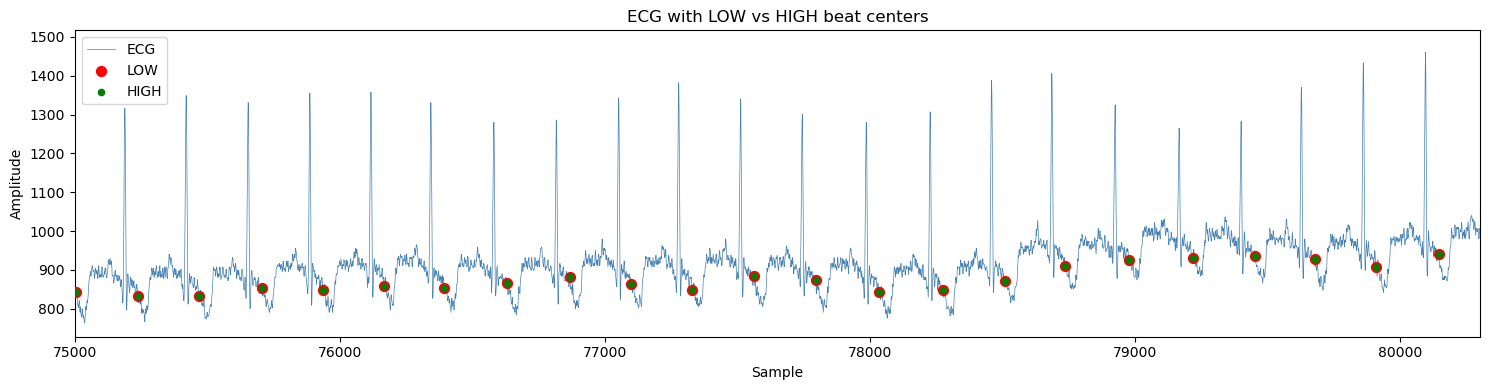

In [6]:
import numpy as np
import matplotlib.pyplot as plt

ecg_path   = "bbdd//mlii_arritmia_cut.txt"
fits_low   = "FITS//MLII_ARRITMIA_FITS_01.txt"
fits_high  = "FITS//MLII_ARRITMIA_HIGH_FITS_01.txt"

ecg = np.loadtxt(ecg_path)  # load raw ECG signal

def extract_samples_with_offsets(fits_path, starting_lines):
    """Uses the actual starting lines of the capture to correct the offset."""
    samples = []
    block = 0
    previous_sample = 0
    with open(fits_path, 'r') as f:
        for line in f:
            if not line.startswith("FIT:"):  # ignore lines that aren't beat fits
                continue
            parts = line.split()
            if len(parts) < 10:  # ignore incomplete lines
                continue
            sample = int(parts[2])
            if sample < previous_sample and block + 1 < len(starting_lines):  # reset detected
                block += 1
            corrected_sample = sample + starting_lines[block]  # apply offset for current block
            previous_sample = sample
            samples.append(corrected_sample)
    return samples

# Starting lines taken from the capture
starting_lines_low  = starting_lines[os.path.basename(fits_low)]
starting_lines_high = [0]  # HIGH config has no reconfigurations, single run

samples_low  = extract_samples_with_offsets(fits_low,  starting_lines_low)
samples_high = extract_samples_with_offsets(fits_high, starting_lines_high)

plt.figure(figsize=(15, 4))
plt.plot(ecg, color='steelblue', linewidth=0.5, label='ECG')
plt.scatter(samples_low,  ecg[samples_low],  color='red',   s=50, zorder=5, label='LOW')   # LOW config beat centers
plt.scatter(samples_high, ecg[samples_high], color='green', s=20, zorder=5, label='HIGH')  # HIGH config beat centers
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("ECG with LOW vs HIGH beat centers")
plt.legend()
plt.tight_layout()
plt.xlim(0+75000, 5300+75000)  # zoom into a specific window of the signal
plt.savefig("LK27.png", dpi=150, bbox_inches='tight')
plt.show()